In [80]:
import pandas as pd
import yaml
import dateparser
from decimal import Decimal
from recordlinkage.index import Full
import recordlinkage

### Helper functions

In [ ]:
# Data loading functions

def load_csv_data(file_path: str) -> pd.DataFrame:
    """Load data from a CSV file into a DataFrame."""
    return pd.read_csv(file_path)

def load_parquet_data(file_path: str) -> pd.DataFrame:
    """Load data from a Parquet file into a DataFrame."""
    return pd.read_parquet(file_path, engine='fastparquet')

def load_yaml_data(file_path: str) -> pd.DataFrame:
    """Load data from a YAML file into a DataFrame."""
    with open(file_path, 'r') as file:
        return pd.DataFrame(yaml.safe_load(file))


# Data cleaning and transformation functions

def extract_price(value: str) -> tuple[Decimal, str] | None:
    """Extract numeric price and currency from a string."""
    price = str(value).strip()
    price = price.lower()
    
    
    euro_symbols = ['€', 'eur', 'euro']
    dollar_symbols = ['$', 'usd', 'dollar']
    if any(sym in price for sym in euro_symbols):
        curr = 'EUR'
    elif any(sym in price for sym in dollar_symbols):
        curr = 'USD'
    else:
        curr = 'UNKNOWN'
        
    for symbol in euro_symbols + dollar_symbols:
        price = price.replace(symbol, '')
        
    price = price.replace('¢', '.')
    price = price.replace(',', '.')
    price = price.replace(' ', '')


    try:
        return (Decimal(price), curr)
    except ValueError:
        return None

# Currency equalization function

def equalize_currency_eur_to_usd(df: pd.DataFrame, exchange_rate: float) -> pd.Series:
    """Convert all prices in EUR to USD using the given exchange rate."""
    def convert(row):
        if row['currency'] == 'EUR':
            row['unit_price'] = round(row['unit_price'] * Decimal(exchange_rate), 2)
            row['currency'] = 'USD'
        return row
    
    return df.apply(convert, axis=1)


# Date parsing function
def parse_df_dates(df: pd.DataFrame, column: str):
    """Parse date strings in the specified column to datetime objects."""
    df[column] = df[column].apply(lambda x: dateparser.parse(x))
    return df

# Extract date from datetime function
def extract_date(df: pd.DataFrame, datetime_column: str, date_column: str):
    """Extract date part from datetime column."""
    df[date_column] = df[datetime_column].dt.date
    return df
    



# User deduplication function
def find_real_users(df, min_matching_fields=3):
    u = df.set_index('id')
    
    pairs = Full().index(u)
    
    compare = recordlinkage.Compare()
    for col in ['name', 'email', 'phone', 'address']:
        compare.exact(col, col)
    
    features = compare.compute(pairs, u)
    matching_pairs = features[features.sum(axis=1) >= min_matching_fields].index
    
    cluster_list = recordlinkage.ConnectedComponents().compute(matching_pairs)
    
    ids_in_clusters = set()
    for cluster in cluster_list:
        ids_in_clusters.update(cluster.get_level_values(0))
        ids_in_clusters.update(cluster.get_level_values(1))
        
    user_to_cluster = {}
    for cluster in cluster_list:
        cluster_ids = set(cluster.get_level_values(0)) | set(cluster.get_level_values(1))
        for user_id in cluster_ids:
            user_to_cluster[user_id] = cluster_ids
    
    return len(cluster_list) + len(set(u.index) - ids_in_clusters), user_to_cluster



# Find how how many unique sets of authors there are. For example, if John and Paul wrote a book together and wrote several books separately, it means that there are 3 different sets.
def count_author_sets(books_df):
    author_sets = books_df[':author'].apply(lambda x: frozenset(x.split(', '))).unique()
    return len(author_sets)


# Find the most popular (by sold book count) author (or author set).
def most_popular_author(books_df, orders_df):
    merged = orders_df.merge(books_df, left_on='book_id', right_on=':id')
    sales = merged.groupby(':author')['quantity'].sum()
    return sales.idxmax()


# Get top user IDs function
def get_top_user_ids(user_claster, top_id):
    
    if user_claster.get(top_id):
        return list(user_claster.get(top_id))
    else:
        return [top_id]


# Prepare data for analysis function
def prepare_data_for_analysis(dfs):
    dfs["orders_df"][["unit_price", "currency"]] = dfs["orders_df"]["unit_price"].apply(lambda x: pd.Series(extract_price(x)))
    equalize_currency_eur_to_usd(dfs["orders_df"], exchange_rate=1.2)
    dfs["orders_df"]["paid_price"] = dfs["orders_df"]["unit_price"] * dfs["orders_df"]["quantity"]
    # Change type to float for easier handling
    dfs["orders_df"]["paid_price"] = dfs["orders_df"]["paid_price"].astype(float)
    parse_df_dates(dfs["orders_df"], "timestamp")
    extract_date(dfs["orders_df"], "timestamp", "date")
    return dfs


# Wrap up function
def wrap_up(dfs):
    dfs = prepare_data_for_analysis(dfs)
    # 1. Compute daily revenue (sum of paid_price grouped by date) and find top 5 days by revenue.
    daily_revenue = dfs["orders_df"].groupby('date', as_index=False)['paid_price'].sum()
    top_5_days = daily_revenue.nlargest(5, 'paid_price')
    
    # 2. Find how many real unique users there are. Note that user can change address or change phone or even provide alias instead of a real name; you need to reconciliate data. You may assume that only one field is changed.
    unique_user_count, user_claster = find_real_users(dfs["users_df"], min_matching_fields=3)
    
    # 3. Find how how many unique sets of authors there are. For example, if John and Paul wrote a book together and wrote several books separately, it means that there are 3 different sets.
    unique_author_sets_count = count_author_sets(dfs["books_df"])
    
    # 4. Find the most popular (by sold book count) author (or author set).
    popular_author = most_popular_author(dfs["books_df"], dfs["orders_df"])
    
    # 5. Identify the top customer by total spending (list all user_id values for the possible different addresses, phones, e-mails, or aliases).
    top_id = dfs["orders_df"].groupby('user_id')['paid_price'].sum().idxmax()
    top_customer_ids = get_top_user_ids(user_claster, top_id)
    
    return {
        "top_5_days": top_5_days,
        "unique_user_count": unique_user_count,
        "unique_author_sets_count": unique_author_sets_count,
        "popular_author": popular_author,
        "top_customer_ids": top_customer_ids
    }

In [82]:
users_df = load_csv_data("data/DATA1/users.csv")

orders_df = load_parquet_data("data/DATA1/orders.parquet")
    
books_df = load_yaml_data("data/DATA1/books.yaml")

dfs = {"users_df": users_df, "orders_df": orders_df, "books_df": books_df}

print(wrap_up(dfs))

{'top_5_days':            date  paid_price
323  2024-12-17    48624.71
279  2024-11-03    42274.16
419  2025-03-23    32917.38
362  2025-01-25    31509.33
67   2024-04-05    28905.75, 'unique_user_count': 3115, 'unique_author_sets_count': 325, 'popular_author': 'Arlinda Huel', 'top_customer_ids': [45800]}


In [83]:
for name, df in dfs.items():
    print(f"DataFrame: {name}")
    print(f"Shape: {df.shape}")
    print(f"Column types:\n{df.dtypes}\n")
    print(f"Missing values:\n{df.isnull().sum()}\n")
    print(f"Duplicates: {df.duplicated().sum()}\n")

DataFrame: users_df
Shape: (3293, 5)
Column types:
id          int64
name       object
address    object
phone      object
email      object
dtype: object

Missing values:
id           0
name         0
address    116
phone        0
email        0
dtype: int64

Duplicates: 0

DataFrame: orders_df
Shape: (11237, 10)
Column types:
id                     int64
user_id                int64
book_id                int64
quantity               int32
unit_price            object
timestamp     datetime64[ns]
shipping              object
currency              object
paid_price           float64
date                  object
dtype: object

Missing values:
id               0
user_id          0
book_id          0
quantity         0
unit_price       0
timestamp        0
shipping      2810
currency         0
paid_price       0
date             0
dtype: int64

Duplicates: 0

DataFrame: books_df
Shape: (753, 6)
Column types:
:id            int64
:title        object
:author       object
:genre        obj

Widzę, że:
- typ danych: orders.timestamp jest nieodpowiedni
- kolumna: unit_price - "(convert everything to dollars and cents, €1 = $1.2)"

In [84]:
orders_df["timestamp"]

0       2024-10-01 10:38:08
1       2024-10-19 10:14:00
2       2025-07-02 22:13:35
3       2025-10-20 16:25:20
4       2024-08-28 08:48:47
                ...        
11232   2025-04-06 04:51:02
11233   2024-06-20 00:38:25
11234   2024-12-11 14:52:00
11235   2025-05-17 11:09:00
11236   2024-09-25 19:54:28
Name: timestamp, Length: 11237, dtype: datetime64[ns]

In [85]:
orders_df["unit_price"]

0        27.00
1        50.50
2        45.99
3        71.00
4        52.25
         ...  
11232    57.99
11233    71.00
11234       50
11235    44.75
11236       28
Name: unit_price, Length: 11237, dtype: object

In [86]:
equalize_currency_eur_to_usd(orders_df, exchange_rate=1.2)

,id,user_id,book_id,quantity,unit_price,timestamp,shipping,currency,paid_price,date
0,71389,47288,18976,2,27.00,2024-10-01 10:38:08,None,USD,54.00,2024-10-01
1,66343,47049,19403,1,60.60,2024-10-19 10:14:00,"4940 Arnoldo Keys, West Arnette, KS 77599",USD,50.50,2024-10-19
2,72606,46685,19500,1,45.99,2025-07-02 22:13:35,,USD,45.99,2025-07-02
3,68462,45336,18992,1,85.20,2025-10-20 16:25:20,,USD,71.00,2025-10-20
4,72691,45311,19388,1,52.25,2024-08-28 08:48:47,None,USD,52.25,2024-08-28
...,...,...,...,...,...,...,...,...,...,...
11232,70045,45032,18966,1,69.59,2025-04-06 04:51:02,"Apt. 657 809 Karisa Dale, Port Moseshire, IN 2...",USD,57.99,2025-04-06
11233,72164,46481,18864,2,71.00,2024-06-20 00:38:25,NULL,USD,142.00,2024-06-20
11234,70697,44686,19083,5,60.00,2024-12-11 14:52:00,NULL,USD,250.00,2024-12-11
11235,64646,46203,19190,1,44.75,2025-05-17 11:09:00,,USD,44.75,2025-05-17


In [87]:
orders_df["paid_price"] = orders_df["unit_price"] * orders_df["quantity"]
orders_df["paid_price"]

0         54.00
1         50.50
2         45.99
3         71.00
4         52.25
          ...  
11232     57.99
11233    142.00
11234       250
11235     44.75
11236       140
Name: paid_price, Length: 11237, dtype: object

In [88]:
orders_df["date"] = orders_df["timestamp"].dt.date
orders_df["date"]

0        2024-10-01
1        2024-10-19
2        2025-07-02
3        2025-10-20
4        2024-08-28
            ...    
11232    2025-04-06
11233    2024-06-20
11234    2024-12-11
11235    2025-05-17
11236    2024-09-25
Name: date, Length: 11237, dtype: object

In [89]:
users_df["id"].duplicated().sum()

np.int64(0)

In [90]:
real_users_count, user_claster = find_real_users(users_df)
print(user_claster)

{45184: {45184, 44875}, 44875: {45184, 44875}, 47440: {47440, 46113, 47508}, 46113: {47440, 46113, 47508}, 47508: {47440, 46113, 47508}, 45665: {45665, 46459}, 46459: {45665, 46459}, 44556: {44556, 44677}, 44677: {44556, 44677}, 45018: {45018, 46178}, 46178: {45018, 46178}, 44738: {44738, 45028}, 45028: {44738, 45028}, 46856: {46856, 45873}, 45873: {46856, 45873}, 46170: {46170, 47340, 44938}, 47340: {46170, 47340, 44938}, 44938: {46170, 47340, 44938}, 45009: {45009, 44395}, 44395: {45009, 44395}, 47370: {47370, 46748}, 46748: {47370, 46748}, 45163: {45163, 44741}, 44741: {45163, 44741}, 46579: {46579, 46012}, 46012: {46579, 46012}, 44480: {44480, 44954}, 44954: {44480, 44954}, 46656: {46656, 46516}, 46516: {46656, 46516}, 46480: {46480, 45349}, 45349: {46480, 45349}, 47418: {47418, 47087}, 47087: {47418, 47087}, 47249: {47249, 46700}, 46700: {47249, 46700}, 44528: {44528, 45091}, 45091: {44528, 45091}, 45914: {45914, 44654}, 44654: {45914, 44654}, 45603: {45603, 44823, 45391}, 44823: 

In [91]:
daily_revenue = orders_df.groupby('date', as_index=False)['paid_price'].sum()

# posortuj od największego do najmniejszego
daily_revenue = daily_revenue.sort_values('paid_price', ascending=False)

# weź top 5 dni
top5_days = daily_revenue.head(5)

In [92]:
top5_days

,date,paid_price
323,2024-12-17,48624.71
279,2024-11-03,42274.16
419,2025-03-23,32917.38
362,2025-01-25,31509.33
67,2024-04-05,28905.75


In [93]:
count_author_sets(books_df)

325

In [94]:
most_popular_author(books_df, orders_df)

'Arlinda Huel'

In [95]:
top_id = orders_df.groupby('user_id')['paid_price'].sum().idxmax()
print(top_id)

45800


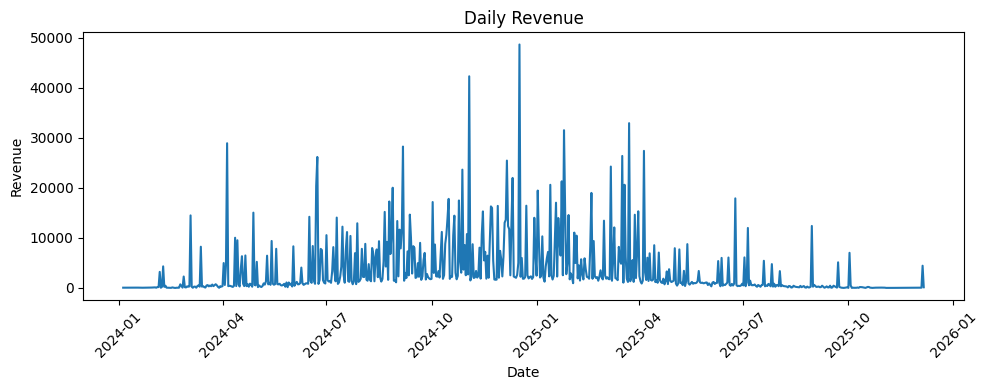

In [96]:
import matplotlib.pyplot as plt
daily_revenue = orders_df.groupby('date', as_index=False)['paid_price'].sum()
plt.figure(figsize=(10,4))
plt.plot(daily_revenue['date'], daily_revenue['paid_price'])
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.title("Daily Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
